<center><h1 style="background-color: #0B1F3A; color: white; padding:10px;"> HR Attrition Risk - Model Training</h1></center>

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

In [3]:
data = pd.read_csv('HR-Employee-Attrition.csv')

In [7]:
data.head(2)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7


In [8]:
data.shape

(1470, 35)

In [9]:
data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [11]:
data.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

## Insert data to Database

In [4]:
# preparing the data for database transfer
data_to_sql = data.drop(columns=['Attrition', 'EmployeeCount', 'Over18', 'StandardHours']).copy()

In [5]:
# mapping the columns name as in database
column_mapping = {
    'Age': 'age',
    'BusinessTravel': 'business_travel',
    'DailyRate': 'daily_rate',
    'Department': 'department',
    'DistanceFromHome': 'distance_from_home',
    'Education': 'education',
    'EducationField': 'education_field',
    'EmployeeNumber': 'employee_id',
    'EnvironmentSatisfaction': 'environment_satisfaction',
    'Gender': 'gender',
    'HourlyRate': 'hourly_rate',
    'JobInvolvement': 'job_involvement',
    'JobLevel': 'job_level',
    'JobRole': 'job_role',
    'JobSatisfaction': 'job_satisfaction',
    'MaritalStatus': 'marital_status',
    'MonthlyIncome': 'monthly_income',
    'MonthlyRate': 'monthly_rate',
    'NumCompaniesWorked': 'num_companies_worked',
    'OverTime': 'overtime',
    'PercentSalaryHike': 'percent_salary_hike',
    'PerformanceRating': 'performance_rating',
    'RelationshipSatisfaction': 'relationship_satisfaction',
    'StockOptionLevel': 'stock_option_level',
    'TotalWorkingYears': 'total_working_years',
    'TrainingTimesLastYear': 'training_times_last_year',
    'WorkLifeBalance': 'work_life_balance',
    'YearsAtCompany': 'years_at_company',
    'YearsInCurrentRole': 'years_in_current_role',
    'YearsSinceLastPromotion': 'years_since_last_promotion',
    'YearsWithCurrManager': 'years_with_curr_manager'
}
data_to_sql = data_to_sql.rename(columns=column_mapping)

In [ ]:
load_dotenv()

DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST = os.getenv('DB_HOST')
DB_PORT = os.getenv('DB_PORT')
DB_NAME = os.getenv('DB_NAME')

engine = create_engine(f'mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

data_to_sql.to_sql(
    name='employee', 
    con=engine, 
    if_exists='append', 
    index=False
)

## Data Preprocessing

In [12]:
all(data.index == data['EmployeeNumber'])

False

This means index is not same as employee number. So we will assign index as employee number to preserve the unique identifier for each employees.

In [14]:
data_new=data.copy()
data_new.set_index('EmployeeNumber', inplace=True)
data_new.head(2)

##### Removing constant columns (with occurrence = 1)

In [16]:
data_new = data_new.drop(columns = ['EmployeeCount', 'Over18', 'StandardHours']).copy()

##### Renaming the columns

In [18]:
data_new = data_new.rename(columns=column_mapping)

##### Converting Attrition column into Binary

In [19]:
data_new['Attrition']=data_new['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

## Exploratory Data Analysis 

In [20]:
data_new['Attrition'].value_counts(normalize = True)*100

0    83.877551
1    16.122449
Name: Attrition, dtype: float64

The data is imbalanced. 

In [22]:
pd.crosstab(data_new['Attrition'], data_new['overtime'], normalize='index' )*100

overtime,No,Yes
Attrition,,
0,76.561233,23.438767
1,46.413502,53.586498


Overtime -> Attrition (How much % does overtime employees are more likely to resign)

In [23]:
pd.crosstab(data_new['overtime'], data_new['Attrition'], normalize='index' )*100

Attrition,0,1
overtime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [24]:
data_new.corr()['Attrition'].sort_values()

total_working_years          -0.171063
job_level                    -0.169105
years_in_current_role        -0.160545
monthly_income               -0.159840
age                          -0.159205
years_with_curr_manager      -0.156199
stock_option_level           -0.137145
years_at_company             -0.134392
job_involvement              -0.130016
job_satisfaction             -0.103481
environment_satisfaction     -0.103369
work_life_balance            -0.063939
training_times_last_year     -0.059478
daily_rate                   -0.056652
relationship_satisfaction    -0.045872
years_since_last_promotion   -0.033019
education                    -0.031373
percent_salary_hike          -0.013478
hourly_rate                  -0.006846
performance_rating            0.002889
monthly_rate                  0.015170
num_companies_worked          0.043494
distance_from_home            0.077924
Attrition                     1.000000
Name: Attrition, dtype: float64

In [26]:
data_new.groupby('business_travel')['Attrition'].mean().sort_values()

business_travel
Non-Travel           0.080000
Travel_Rarely        0.149569
Travel_Frequently    0.249097
Name: Attrition, dtype: float64

In [27]:
data_new.groupby('department')['Attrition'].mean().sort_values()

department
Research & Development    0.138398
Human Resources           0.190476
Sales                     0.206278
Name: Attrition, dtype: float64

In [28]:
data_new.groupby('education_field')['Attrition'].mean().sort_values()

education_field
Other               0.134146
Medical             0.135776
Life Sciences       0.146865
Marketing           0.220126
Technical Degree    0.242424
Human Resources     0.259259
Name: Attrition, dtype: float64

In [29]:
data_new.groupby('gender')['Attrition'].mean().sort_values()

gender
Female    0.147959
Male      0.170068
Name: Attrition, dtype: float64

In [30]:
data_new.groupby('job_role')['Attrition'].mean().sort_values()

job_role
Research Director            0.025000
Manager                      0.049020
Healthcare Representative    0.068702
Manufacturing Director       0.068966
Research Scientist           0.160959
Sales Executive              0.174847
Human Resources              0.230769
Laboratory Technician        0.239382
Sales Representative         0.397590
Name: Attrition, dtype: float64

In [31]:
data_new.groupby('overtime')['Attrition'].mean().sort_values()

overtime
No     0.104364
Yes    0.305288
Name: Attrition, dtype: float64

In [32]:
data_new.groupby('marital_status')['Attrition'].mean().sort_values()

marital_status
Divorced    0.100917
Married     0.124814
Single      0.255319
Name: Attrition, dtype: float64

## Train/Test Split

In [33]:
x = data_new.drop(columns=['Attrition']).copy()
y = data_new['Attrition']

In [34]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                   test_size = 0.2,
                                                   random_state = 42,
                                                   stratify = y 
                                                   )

In [35]:
y_train.value_counts(normalize = True)*100

0    83.843537
1    16.156463
Name: Attrition, dtype: float64

In [36]:
y_test.value_counts(normalize = True)*100

0    84.013605
1    15.986395
Name: Attrition, dtype: float64

###  Encoding Features

In [37]:
import joblib

# 1. Ordinal + Binary mappings
mappings = {
    'business_travel': {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2},# Ordinal Mapping (order matters)
    'gender': {'Male': 0, 'Female': 1}, # Binary Mapping
    'overtime': {'No': 0, 'Yes': 1} # Binary Mapping
}
joblib.dump(mappings, 'mappings.pkl')

for col, mapping in mappings.items():
    x_train[col] = x_train[col].map(mapping)
    x_test[col] = x_test[col].map(mapping)


In [38]:
# One-hot encoding (no natural order)
from sklearn.preprocessing import OneHotEncoder

cols_to_transform = ['department', 'job_role', 'education_field', 'marital_status']
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
encoder.fit(x_train[cols_to_transform])

def apply_encoding(df, encoder, cols):
    encoded_arr = encoder.transform(df[cols])
    encoded_df = pd.DataFrame(encoded_arr, columns=encoder.get_feature_names_out(cols), index=df.index)
    encoded_df = encoded_df.astype(int)
    return pd.concat([df.drop(columns = cols), encoded_df], axis=1)

x_train_encoded = apply_encoding(x_train, encoder, cols_to_transform)
x_test_encoded = apply_encoding(x_test, encoder, cols_to_transform) 

# saving the encoder
joblib.dump(encoder, 'encoder.pkl')

['encoder.pkl']

In [39]:
data_new.columns

Index(['age', 'Attrition', 'business_travel', 'daily_rate', 'department',
       'distance_from_home', 'education', 'education_field',
       'environment_satisfaction', 'gender', 'hourly_rate', 'job_involvement',
       'job_level', 'job_role', 'job_satisfaction', 'marital_status',
       'monthly_income', 'monthly_rate', 'num_companies_worked', 'overtime',
       'percent_salary_hike', 'performance_rating',
       'relationship_satisfaction', 'stock_option_level',
       'total_working_years', 'training_times_last_year', 'work_life_balance',
       'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager'],
      dtype='object')

In [40]:
x_test_encoded.head(2)

,age,business_travel,daily_rate,distance_from_home,education,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,...,job_role_Research Scientist,job_role_Sales Executive,job_role_Sales Representative,education_field_Life Sciences,education_field_Marketing,education_field_Medical,education_field_Other,education_field_Technical Degree,marital_status_Married,marital_status_Single
EmployeeNumber,,,,,,,,,,,,,,,,,,,,,
1495,24,0,830,13,2,4,1,78,3,1,...,0,0,1,1,0,0,0,0,1,0
1246,44,1,1117,2,1,1,1,72,4,1,...,1,0,0,1,0,0,0,0,1,0


### Removing Multicollinear Features   

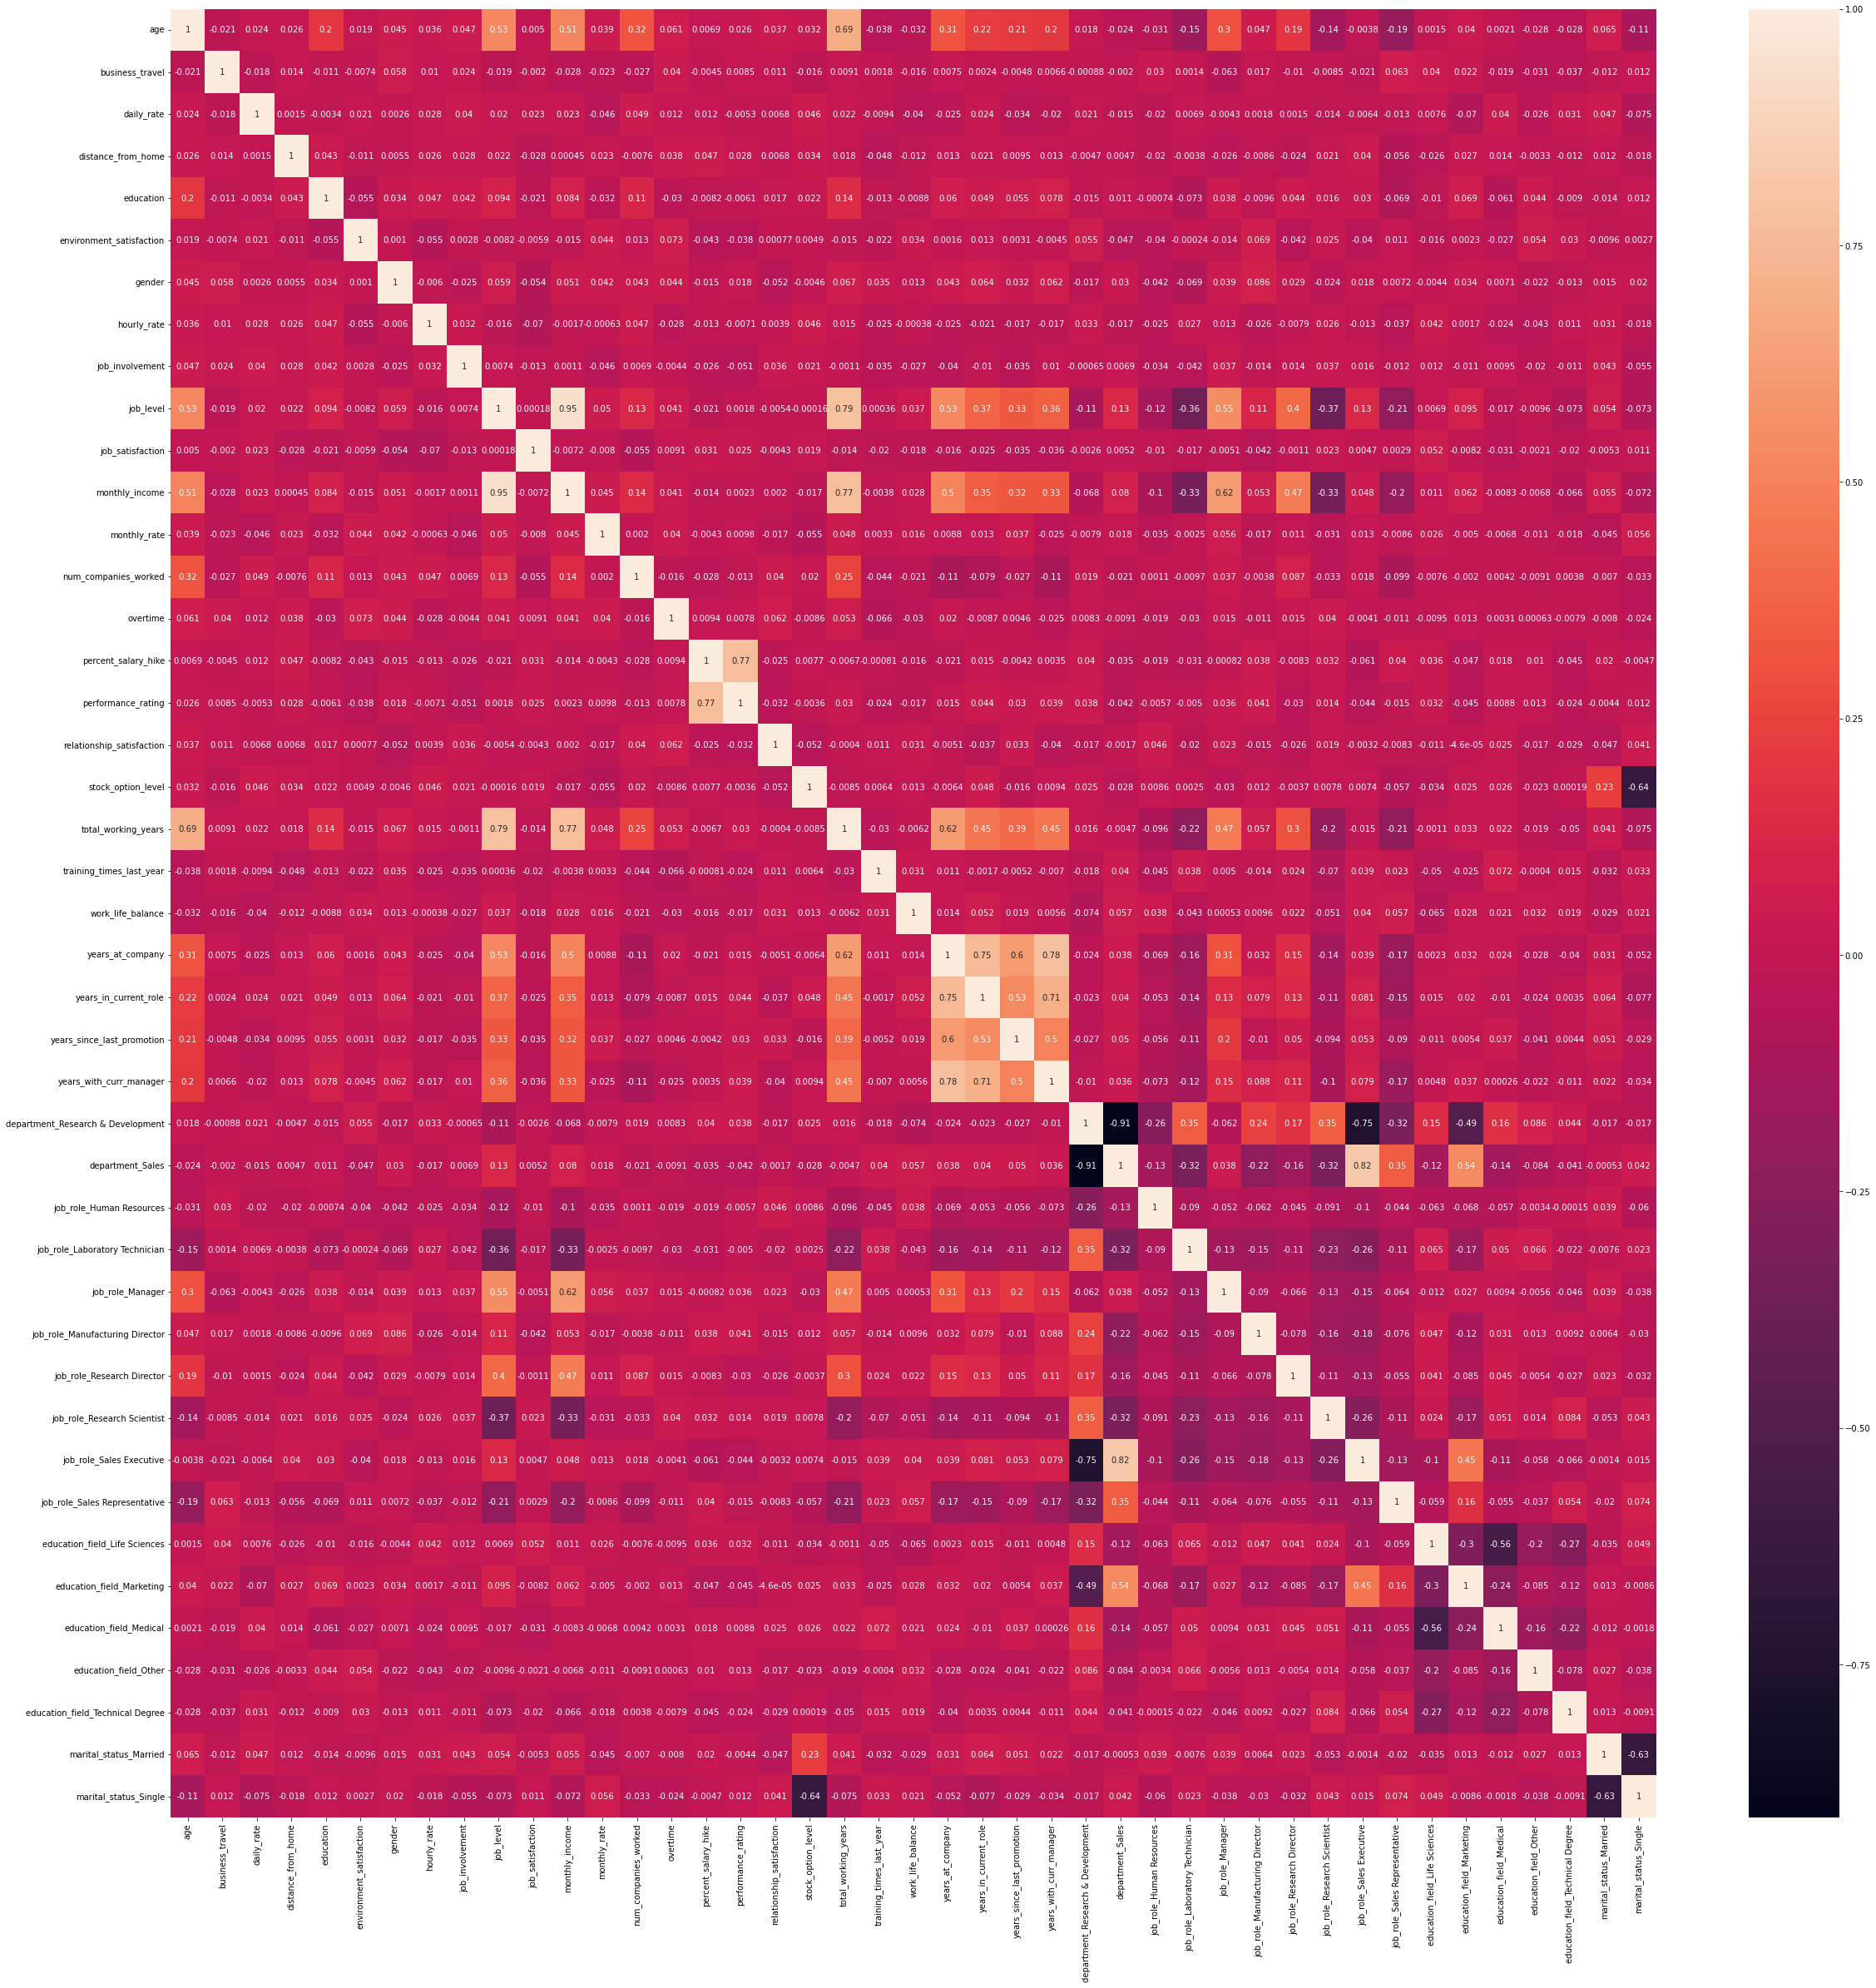

In [41]:
corr_matrix = x_train_encoded.corr()

fig = plt.figure(figsize=(40,40))

sns.heatmap(corr_matrix, annot = True)
plt.show()

In [42]:
high_corr = corr_matrix.where((abs(corr_matrix) > 0.75) & (corr_matrix != 1.0))
high_corr.stack().sort_values(ascending=False)

job_level                          monthly_income                       0.947008
monthly_income                     job_level                            0.947008
department_Sales                   job_role_Sales Executive             0.821230
job_role_Sales Executive           department_Sales                     0.821230
job_level                          total_working_years                  0.785244
total_working_years                job_level                            0.785244
years_at_company                   years_with_curr_manager              0.776416
years_with_curr_manager            years_at_company                     0.776416
monthly_income                     total_working_years                  0.774830
total_working_years                monthly_income                       0.774830
percent_salary_hike                performance_rating                   0.773922
performance_rating                 percent_salary_hike                  0.773922
department_Research & Develo

In [44]:
drop_cols = ['job_level','performance_rating', 'total_working_years', 'years_with_curr_manager', 'years_in_current_role', 'department_Sales']

x_train_clean = x_train_encoded.drop(columns=drop_cols).copy()
x_test_clean = x_test_encoded.drop(columns=drop_cols).copy()

In [45]:
x_train_clean.shape

(1176, 37)

In [46]:
joblib.dump(list(x_train_clean.columns), 'feature_cols.pkl')

['feature_cols.pkl']

### Outlier Detection 

In [47]:
x_train_clean.columns

Index(['age', 'business_travel', 'daily_rate', 'distance_from_home',
       'education', 'environment_satisfaction', 'gender', 'hourly_rate',
       'job_involvement', 'job_satisfaction', 'monthly_income', 'monthly_rate',
       'num_companies_worked', 'overtime', 'percent_salary_hike',
       'relationship_satisfaction', 'stock_option_level',
       'training_times_last_year', 'work_life_balance', 'years_at_company',
       'years_since_last_promotion', 'department_Research & Development',
       'job_role_Human Resources', 'job_role_Laboratory Technician',
       'job_role_Manager', 'job_role_Manufacturing Director',
       'job_role_Research Director', 'job_role_Research Scientist',
       'job_role_Sales Executive', 'job_role_Sales Representative',
       'education_field_Life Sciences', 'education_field_Marketing',
       'education_field_Medical', 'education_field_Other',
       'education_field_Technical Degree', 'marital_status_Married',
       'marital_status_Single'],
      d

In [48]:
x_train_clean[['monthly_income','years_at_company','daily_rate',
               'distance_from_home','hourly_rate','monthly_rate','num_companies_worked',
              'percent_salary_hike','stock_option_level','training_times_last_year','years_since_last_promotion']].describe()

,monthly_income,years_at_company,daily_rate,distance_from_home,hourly_rate,monthly_rate,num_companies_worked,percent_salary_hike,stock_option_level,training_times_last_year,years_since_last_promotion
count,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000
mean,6544.024660,7.050170,803.991497,9.357993,65.500000,14390.239796,2.693027,15.239796,0.790816,2.760204,2.182823
std,4653.743955,6.086612,401.339423,8.179803,20.373324,7192.834394,2.486077,3.679081,0.845786,1.256262,3.215348
min,1009.000000,0.000000,103.000000,1.000000,30.000000,2094.000000,0.000000,11.000000,0.000000,0.000000,0.000000
25%,2948.000000,3.000000,467.750000,2.000000,48.000000,8051.000000,1.000000,12.000000,0.000000,2.000000,0.000000
50%,5004.500000,5.000000,799.500000,7.000000,66.000000,14373.000000,2.000000,14.000000,1.000000,3.000000,1.000000
75%,8420.500000,10.000000,1157.000000,14.000000,83.000000,20770.750000,4.000000,18.000000,1.000000,3.000000,3.000000
max,19973.000000,37.000000,1499.000000,29.000000,100.000000,26999.000000,9.000000,25.000000,3.000000,6.000000,15.000000


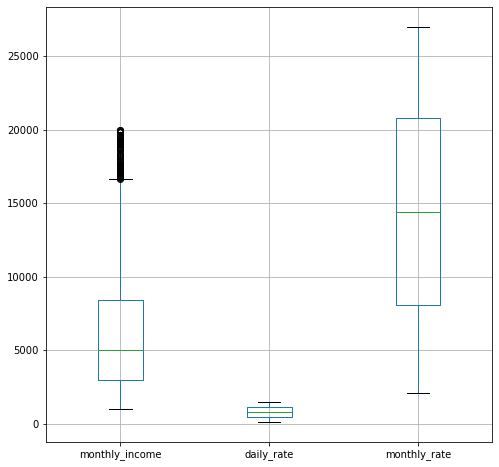

<Figure size 432x288 with 0 Axes>

In [49]:
x_train_clean[['monthly_income','daily_rate','monthly_rate']].boxplot(figsize=(8,8))
plt.show()
plt.savefig('outlier2.png')

In [50]:
print(x_train_clean['monthly_income'].quantile(0.01))
print(x_train_clean['monthly_income'].quantile(0.05))
print(x_train_clean['monthly_income'].quantile(0.95))
print(x_train_clean['monthly_income'].quantile(0.99))

1410.25
2115.5
17490.5
19592.75


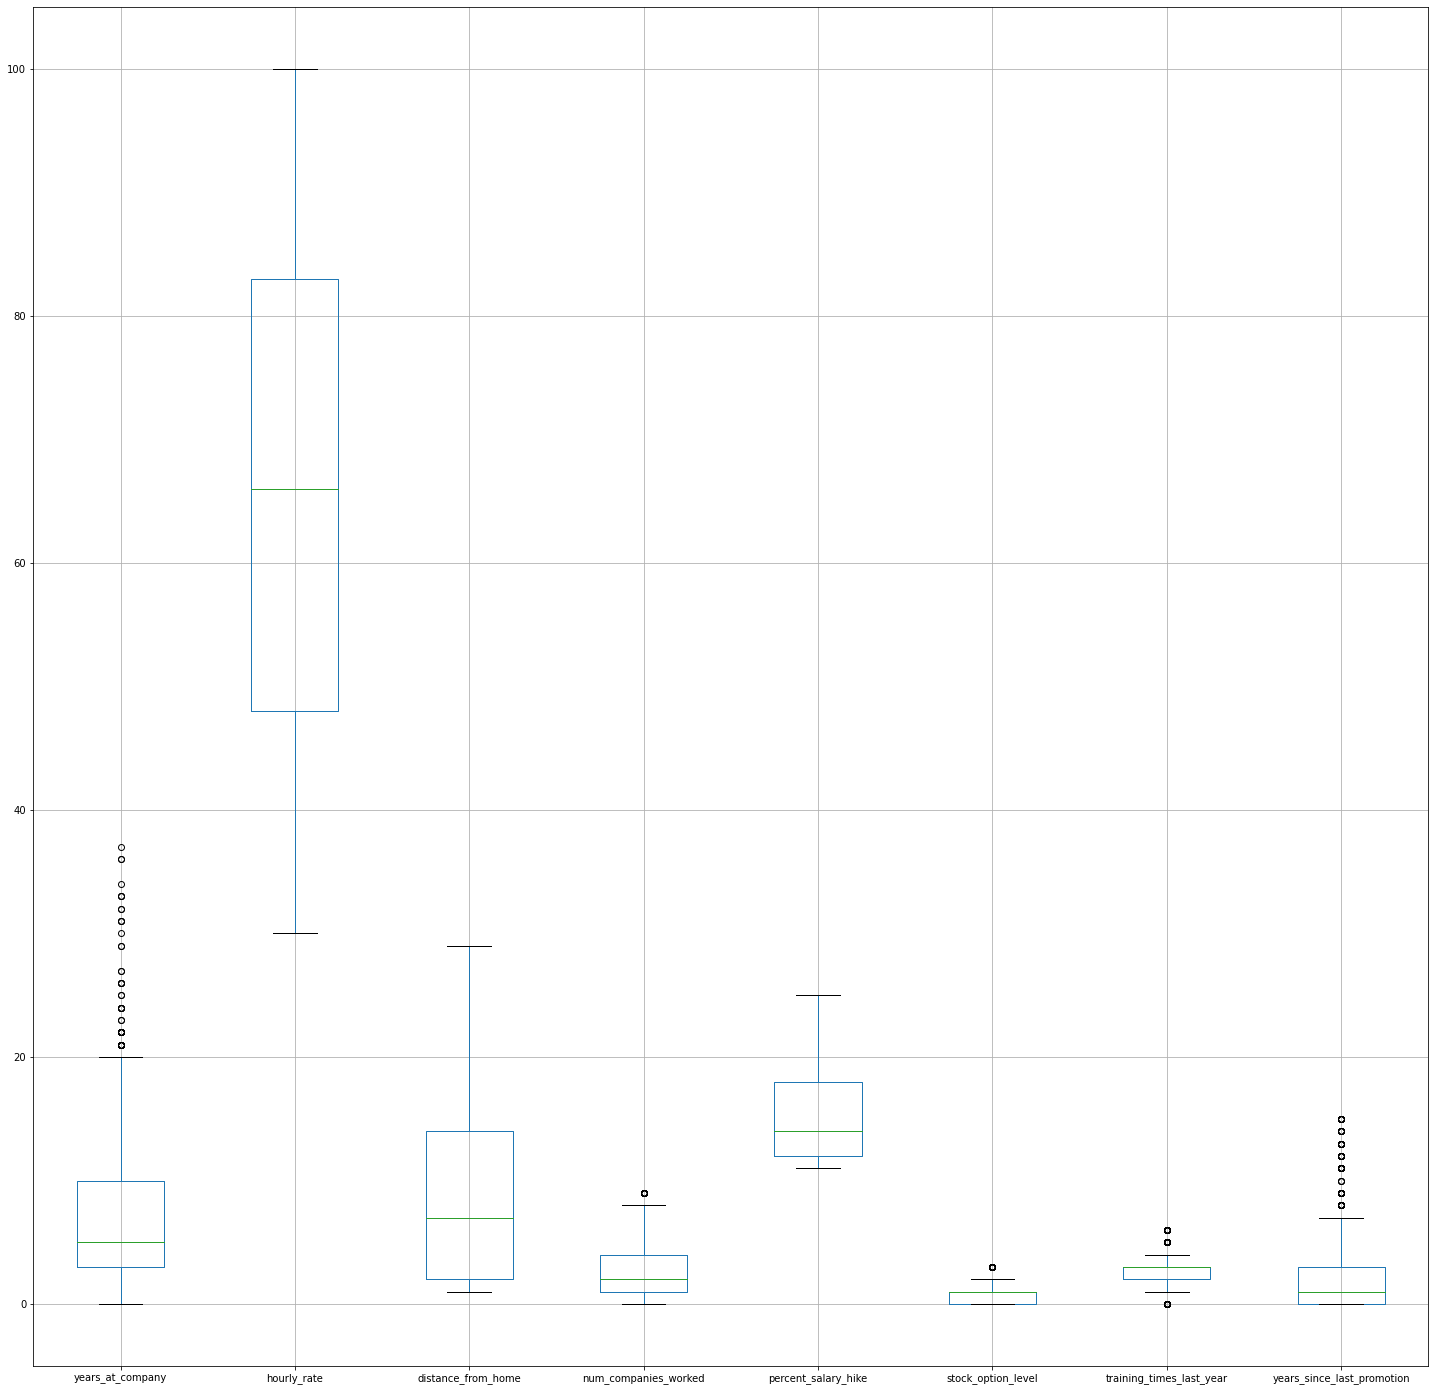

<Figure size 432x288 with 0 Axes>

In [51]:
x_train_clean[['years_at_company','hourly_rate',
               'distance_from_home','num_companies_worked',
              'percent_salary_hike','stock_option_level','training_times_last_year','years_since_last_promotion']].boxplot(figsize=(25,25))
plt.show()
plt.savefig('outlier.png')

In [52]:
print(x_train_clean['years_at_company'].quantile(0.01))
print(x_train_clean['years_at_company'].quantile(0.05))
print(x_train_clean['years_at_company'].quantile(0.95))
print(x_train_clean['years_at_company'].quantile(0.99))

0.0
1.0
20.0
30.25


In [53]:
print(x_train_clean['years_since_last_promotion'].quantile(0.01))
print(x_train_clean['years_since_last_promotion'].quantile(0.05))
print(x_train_clean['years_since_last_promotion'].quantile(0.95))
print(x_train_clean['years_since_last_promotion'].quantile(0.99))

0.0
0.0
9.0
14.0


## Model Creation

### Logistic Regression (Baseline Model)

####   Normalization

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_clean)
x_test_scaled = scaler.transform(x_test_clean)

In [55]:
x_train_scaled

array([[ 1.09019402, -0.16150971,  1.04945488, ..., -0.3292238 ,
        -0.92144268, -0.68154831],
       [-1.6348276 , -0.16150971, -0.52344929, ...,  3.03744744,
         1.08525471, -0.68154831],
       [ 0.98119316, -0.16150971, -0.99208001, ..., -0.3292238 ,
         1.08525471, -0.68154831],
       ...,
       [-1.6348276 , -0.16150971, -1.46320345, ..., -0.3292238 ,
         1.08525471, -0.68154831],
       [-0.10881549, -0.16150971, -0.93225481, ..., -0.3292238 ,
         1.08525471, -0.68154831],
       [ 0.21818711,  1.70060225, -0.09470203, ..., -0.3292238 ,
        -0.92144268, -0.68154831]])

#### Model Training  

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression(random_state = 42, class_weight = 'balanced', max_iter = 1000)

In [57]:
model.fit(x_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [58]:
y_pred = model.predict(x_test_scaled)

print(f'Classification Report:\n {classification_report(y_test, y_pred)}')
print(f'\nConfusion Matrix:\n {confusion_matrix(y_test, y_pred)}')

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86       247
           1       0.39      0.66      0.49        47

    accuracy                           0.78       294
   macro avg       0.66      0.73      0.67       294
weighted avg       0.84      0.78      0.80       294


Confusion Matrix:
 [[198  49]
 [ 16  31]]


###  Random Forest (Final Model)

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [60]:
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_leaf_nodes': [10, 20, 30, None]
}

model_init = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_model = GridSearchCV(
    model_init,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_model.fit(x_train_clean, y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'max_leaf_nodes': [10, 20, 30, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 150, 200]},
             scoring='recall')

In [61]:
grid_model.best_params_

{'max_depth': 10,
 'max_leaf_nodes': 10,
 'min_samples_split': 10,
 'n_estimators': 200}

In [62]:
best_rf = grid_model.best_estimator_
y_predict_random = best_rf.predict(x_test_clean)

In [63]:
print(f'Classification Report:\n {classification_report(y_test, y_predict_random)}')
print(f'\nConfusion Matrix:\n {confusion_matrix(y_test, y_predict_random)}')

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.83      0.87       247
           1       0.39      0.60      0.47        47

    accuracy                           0.79       294
   macro avg       0.65      0.71      0.67       294
weighted avg       0.83      0.79      0.81       294


Confusion Matrix:
 [[204  43]
 [ 19  28]]


### Threshold Tuning

In [64]:
final_threshold = 0.4   # chosen after comparing 0.5 -> 0.25, balances recall vs precision

In [65]:
y_probability = best_rf.predict_proba(x_test_clean)[:,1]

In [66]:
y_pred_final = (y_probability >= final_threshold).astype(int)

In [68]:
print(f"Final Model (Random Forest, threshold={final_threshold}):")
print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))

Final Model (Random Forest, threshold=0.4):
              precision    recall  f1-score   support

           0       0.95      0.59      0.73       247
           1       0.28      0.85      0.43        47

    accuracy                           0.63       294
   macro avg       0.62      0.72      0.58       294
weighted avg       0.85      0.63      0.68       294

[[146 101]
 [  7  40]]


#### Saving model

In [69]:
joblib.dump(best_rf, 'model.pkl')

['model.pkl']

###  Model Explaination (using SHAP)

In [70]:
best_rf.feature_importances_

array([0.12854423, 0.01561581, 0.03758542, 0.03327323, 0.00523059,
       0.03255656, 0.00263915, 0.01872535, 0.01612877, 0.0219745 ,
       0.13699561, 0.02404017, 0.03595413, 0.09549211, 0.01324509,
       0.01174765, 0.07345362, 0.00637502, 0.0122532 , 0.12458512,
       0.01147662, 0.01586934, 0.00085197, 0.02351713, 0.00383983,
       0.00653812, 0.00564991, 0.00744756, 0.01407994, 0.01326858,
       0.00194448, 0.00438864, 0.00445463, 0.0001907 , 0.00063199,
       0.00610272, 0.03333248])

In [71]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(x_test_clean)

In [72]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(294, 37, 2)


In [73]:
shap_values_class1 = shap_values[:, :, 1]
print(shap_values_class1.shape)

(294, 37)


In [74]:
explainer.expected_value

array([0.49780383, 0.50219617])

Employee index: 200, Probability: 0.80


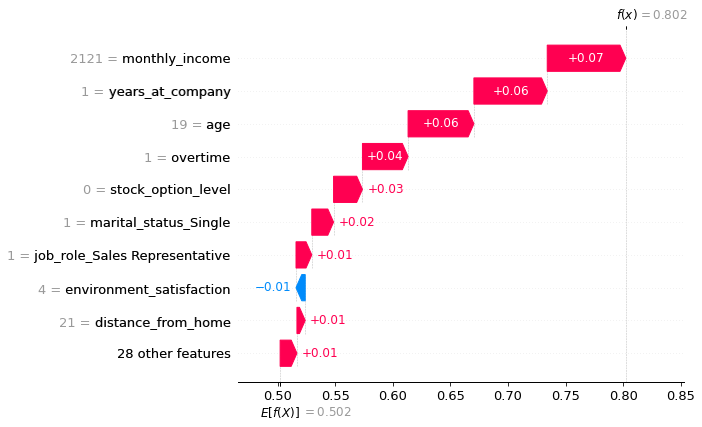

In [75]:
highest_risk_idx = np.argmax(y_probability)   
print(f"Employee index: {highest_risk_idx}, Probability: {y_probability[highest_risk_idx]:.2f}")

# visualize the explanation, why our model predicted this employee at high risk of Attrition.
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_class1[highest_risk_idx],
        base_values=explainer.expected_value[1],
        data=x_test_clean.iloc[highest_risk_idx],
        feature_names=x_test_clean.columns.tolist()
    )
)

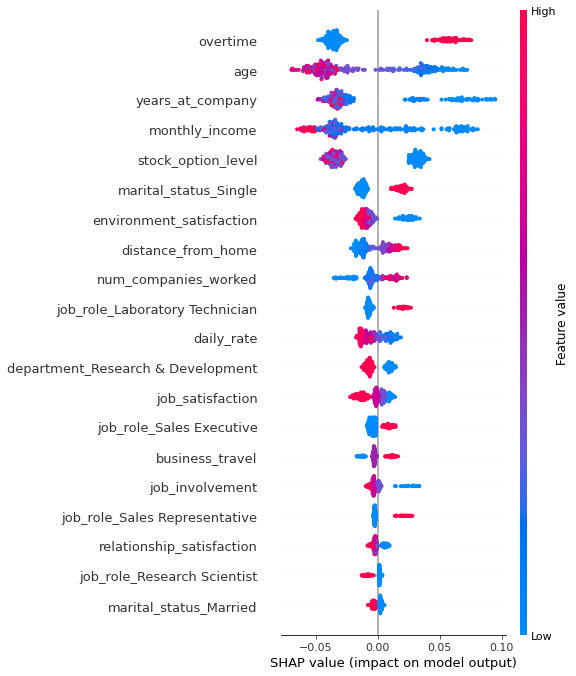

In [76]:
shap.summary_plot(shap_values_class1, x_test_clean)

OverTime, YearsAtCompany, MonthlyIncome, Age, StockOptionLevel are overall top drivers 

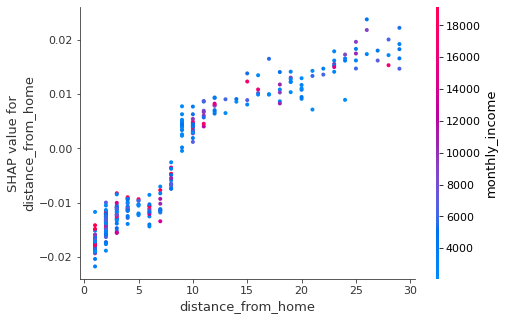

In [78]:
shap.dependence_plot('distance_from_home', shap_values_class1, x_test_clean, interaction_index='monthly_income')

####  Top 3 Drivers for each employee

In [68]:
results = []

for i in range(len(x_test_clean)):
    employee_shap_value = shap_values_class1[i]
    feature_impact = list(zip(x_test_clean.columns.tolist(), employee_shap_value))
    top_3 = sorted(feature_impact, key=lambda x: abs(x[1]), reverse=True)[:3]
    
    results.append({
        'employee_id': x_test_clean.index[i],
        'attrition_probability': round(y_probability[i], 3),
        'risk_label': 'High Risk' if y_probability[i] >= final_threshold else 'Low Risk',
        'top_driver_1': top_3[0][0],
        'top_driver_1_impact': round(top_3[0][1], 3),
        'top_driver_2': top_3[1][0],
        'top_driver_2_impact': round(top_3[1][1], 3),
        'top_driver_3': top_3[2][0],
        'top_driver_3_impact': round(top_3[2][1], 3),
    })

final_output = pd.DataFrame(results)
final_output.head(10)

,employee_id,attrition_probability,risk_label,top_driver_1,top_driver_1_impact,top_driver_2,top_driver_2_impact,top_driver_3,top_driver_3_impact
0,1495,0.643,High Risk,YearsAtCompany,0.092,MonthlyIncome,0.077,Age,0.058
1,1246,0.321,Low Risk,MonthlyIncome,0.063,EnvironmentSatisfaction,0.020,YearsSinceLastPromotion,0.002
2,613,0.334,Low Risk,Age,0.028,NumCompaniesWorked,0.017,Department_Research & Development,0.012
3,1288,0.212,Low Risk,JobSatisfaction,0.006,YearsSinceLastPromotion,0.003,MaritalStatus_Married,0.001
4,90,0.449,High Risk,YearsAtCompany,0.065,OverTime,0.046,DailyRate,0.006
5,1641,0.444,High Risk,OverTime,0.058,StockOptionLevel,0.034,NumCompaniesWorked,0.017
6,543,0.362,Low Risk,OverTime,0.053,StockOptionLevel,0.032,DailyRate,0.007
7,1866,0.326,Low Risk,StockOptionLevel,0.032,EnvironmentSatisfaction,0.027,NumCompaniesWorked,0.017
8,1728,0.239,Low Risk,DistanceFromHome,0.016,JobRole_Research Scientist,0.001,EducationField_Medical,0.001
9,1839,0.690,High Risk,YearsAtCompany,0.080,Age,0.069,MonthlyIncome,0.065


In [69]:
final_output['risk_label'].value_counts()

Low Risk     153
High Risk    141
Name: risk_label, dtype: int64